# **Assignment 9**
This exercise has two parts:

- Part A consists of mandatory exercises; you need to complete these and hand in your answers to be able to partake in the exam. This part also provides you with an impression of the minimum knowledge level necessary to pass the exam.
- Part B consists of additional exercises. These repeat a concept that is covered in Part A or help to broaden or deepen your understanding of some of the topics.  

## Assignment by
Lan Stare, s1169977

Aaron Ritz, s1170346

## Advised Reading and Exercise Material
**The following reading material is recommended:**

Read and study chapter 5 of TSK. You can skip section 5.2.6.

## Additional Tools
For this exercise you will need to load the provided *clusterPlot.py* script from the toolbox folder. 


## Introduction
In previous exercises we considered supervised learning, i.e., we were given both input data **X** and output values **Y**. We now move on to unsupervised learning where we are only provided input data **X**. The aim is here to find common patterns in the data such as groups of observations that are similar in some sense. 


# **Part A** - Mandatory Exercises
Below you will find the mandatory exercises for Week 4 of the course Data Mining and Machine Learning.

## Exercise 1 - *k*-means clustering
In this part of the exercise we will investigate *k*-means clustering. In *k*-means each of the data points are assigned to the cluster in closest proximity according to some measure of distance between cluster centers and data points. When the distance is given by the squared euclidian distance, the centers are also called centroids. Once the data points have been assigned, each cluster center is updated to be placed at the center of the data points that are assigned to the cluster. This continues iteratively, usually until the assignment of data points to centers no longer changes or until a maximal number of iterations is reached.

### Exercise 1.1
Implement the K-means algorithm. Pseudo-code for this algorithm is given in section
5.2.1 of TSK, Algorithm 5.1. Use the standard (squared) Euclidean distance.

**Helpful hints:**
 + You can sample k random datapoints from some dataset d using random.sample(d,k)

In [121]:
import numpy as np
import random

def squared_euclidean(x, y):
    return np.linalg.norm(x - y)

def initialize_centroids(data, k):
    idx = random.sample(range(len(data)), k)
    return [data[i] for i in idx]

def assign_cluster(data, centroids):
    labels = []   # cluster index for each point

    for point in data:
        # compute distances to each centroid
        distances = [squared_euclidean(point, c) for c in centroids]
        # pick the closest centroid index
        closest = int(np.argmin(distances))
        labels.append(closest)

    return labels


def compute_centroid(data, labels, k):
    new_centroids = []
    for c in range(k):
        pts = [data[i] for i in range(len(data)) if labels[i] == c]
        new_centroids.append(np.mean(pts, axis=0))
    return np.array(new_centroids)



In [ ]:
# Write your code for 1.1 here, ideally use the helper functions
# return both your final cluster assignments, and the centroids!

def kmeans(data, k, tolerance=1e-4, max_iter=300):  #I added max_iter for safety although it usually converges quickly :)
    centroids = initialize_centroids(data, k)

    for _ in range(max_iter):
        labels = assign_cluster(data, centroids)
        new_centroids = compute_centroid(data, labels, k)

        movement = np.sum([
            squared_euclidean(centroids[i], new_centroids[i])
            for i in range(k)
        ])

        centroids = new_centroids

        if movement < tolerance:
            break

    return np.array(labels), centroids


### Exercise 1.2
Load the `synth1` data into python using the `loadmat` function. The `synth1` data is a Matfile loaded into Python as a dictionary; the relevant data is contained under keys `X` and `y`. Cluster the data into `K = 4` clusters using the *k*-means algorithm. Make a scatter plot of the data and the clustering using the provided `clusterPlot()` function from the toolbox. Move the legend if the position is obfuscating data.

**Helpful hints:**
 + Type `clusterPlot(X,clusters,centroids,y)` to plot the data and the clustering. Don't forget to import the function from the `toolbox` folder. If you are unsure about how to use the function, open the .py file in a text editor and take a look at documentation.
 + Make sure that your code from 1.1 returns the clusters and centroids properly!

[[ 0.41819347  0.72505978]
 [ 1.16077592  1.25372183]
 [ 0.99195122  0.57332584]
 [ 1.05911131  1.14392175]
 [ 0.86661635  1.14353708]
 [ 1.01605275  1.52383058]
 [ 0.99381613  1.36534343]
 [ 1.14670371  1.43107459]
 [ 0.90348822  1.01994253]
 [ 1.14103296  0.91031573]
 [ 1.22114579  0.71690785]
 [ 0.38908409  1.30626919]
 [ 1.02521334  1.24365688]
 [ 0.82213277  0.92948993]
 [ 1.02862273  1.56489411]
 [ 1.19196182  1.16853147]
 [ 0.88276935  0.59449177]
 [ 1.28061581  0.79919027]
 [ 1.4206002   1.12939987]
 [ 1.33783214  0.99801456]
 [ 0.51167748  0.7437484 ]
 [ 0.53556441  1.38879855]
 [ 1.24951175  0.58850582]
 [ 0.91006184  1.07815047]
 [ 1.33773105  0.53949808]
 [ 1.36182023  0.61468247]
 [ 0.58067327  0.83714056]
 [ 1.01520555  1.10036993]
 [ 1.24044894  1.11473397]
 [ 1.0960145   0.98346027]
 [ 1.01175877  1.38436726]
 [ 1.38585908  1.35374649]
 [ 0.90584544  1.53428867]
 [ 0.92207457  1.37561863]
 [ 1.39016089  1.31454408]
 [ 0.91283882  1.04737244]
 [ 0.87510962  0.80762173]
 

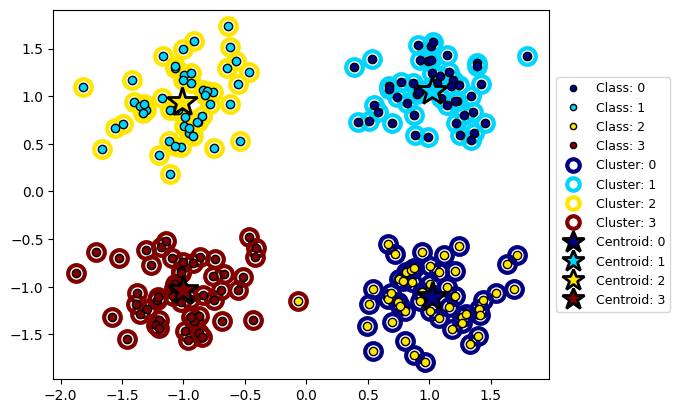

In [154]:
## Answer to exercise 1.2

import scipy.io as si
from toolbox import clusterPlot as cp

X = si.loadmat('data/synth1.mat')['X']      #n x 2 matrix of points
y = si.loadmat('data/synth1.mat')['y']      #true class labels
print(X)
#print(y)

#plotting the clusterPlot:
clusters, centroids = kmeans(X, 4)
cp.clusterPlot(X, clusters, centroids, y)



### Exercise 1.3
Download the dataset from http://www.cs.ru.nl/~tomh/onderwijs/dm/dm_files/dataforkmeans.csv. Plot a scatterplot to inspect the data and see what it looks like.

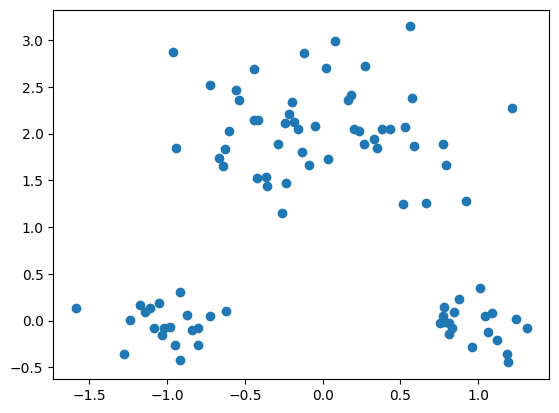

In [157]:
## Answer to exercise 1.3
import pandas as pd
import matplotlib.pyplot as plt

data2 = pd.read_csv("dataforkmeans.csv")
x21, x22 = data2.iloc[:, 0], data2.iloc[:, 1]
plt.scatter(x21, x22)

### Exercise 1.4
Apply your K-means algorithm from 1.1 to the dataset from 1.3. Play around with different values of K (the number of clusters) and plot a typical result for K = 5.

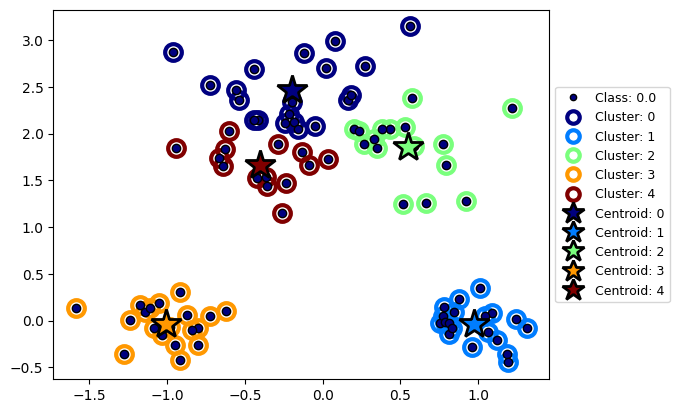

In [ ]:
## Answer to exercise 1.4
x3 = np.array(list(zip(data2.iloc[:, 0], data2.iloc[:, 1])))

clusters5, centroids5 = kmeans(x3, 5)
cp.clusterPlot(x3, clusters5, centroids5)

### Exercise 1.5
Run the K-means algorithm from different initializations for K = 3.

How many different solutions do you get? What are the typical solutions when you categorize these solutions? Either
sketch or describe these.

**Helpful hints:**
 - initialize the means to 3 different randomly chosen data points
 - You will (hopefully) find that many of these solutions are somewhat
similar.

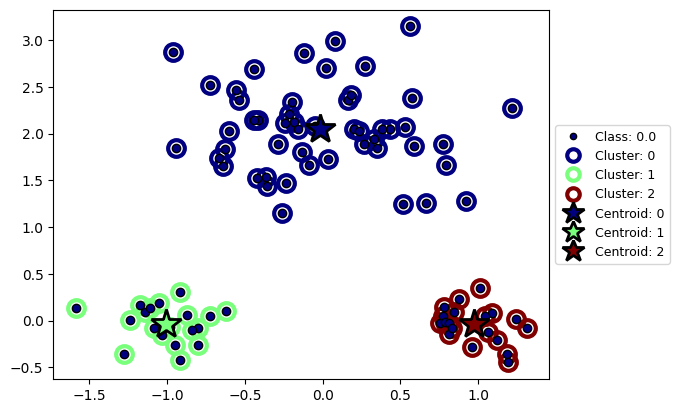

In [224]:
## Answer to exercise 1.5
clusters3, centroids3 = kmeans(x3, 3)
cp.clusterPlot(x3, clusters3, centroids3)

ANSWER:
You mostly get 2 very different solutions. The first solution you get is when one centroid is at approximately (-1.0, 0.0), another one at approx. (1.0, 0.0) and the third one at approx. (0.0, 2.0). The second solution you get if when one centroid is at approx. (0.0, 0.0), another one at approx. (-0.5, 2.0) and the third one at (0.5, 2.0). There are about 2 more solutions that you get but are very similar to the second one.

## Exercise 2 - *k*-means initialization
The way our original centroids are selected can have a massive impact on the final performance of $k$-means. In the table below we provide a set of points, this set is visualised in the image in the cell below as well. Clearly these points form 3 distinct clusters, right?

| Point | X   | Y   |
| :---- | :-- | :-- |
| A₁    | 1.0 | 1.0 |
| A₂    | 1.2 | 0.8 |
| A₃    | 0.8 | 1.2 |
| B₁    | 5.0 | 5.0 |
| B₂    | 5.2 | 4.8 |
| B₃    | 4.8 | 5.2 |
| C₁    | 9.0 | 1.0 |
| C₂    | 9.2 | 0.8 |
| C₃    | 8.8 | 1.2 |


![alt text](initialization.png?nocache=1 "Title")

### Exercise 2.1
If you take your initial centroids to be $A_1$, $B_1$ and $C_1$, briefly describe what you expect to happen after $k$-means clustering.

ANSWER:
After k-means clustering, the final centroids would not change. The algorithm would run for exactly 1 iteration and then stop, since the centroids wouldldn't change.

### Exercise 2.2
Is there any initialization with $k=3$ for which you see undesired behaviour? Give an example of such an initialization and explain why this would go wrong.

ANSWER:
Yes, if we choose A1, A2 and B1 as initial centroids, we would get undesired behaviour. Since the distance between B'a and C's is shorter, C1, C2 and C3 would all be asigned to B1 in the first iteration. That would mean that the centroid B2 would move in between B1, C1, C2 and C3, whereas A3 would be assigned to A1, so the centroid A1 would shift in between A1 and A3. A2 wouldn't budge. The centroids wouldn't change after that, since all C's would still be assigned to the centroid that was once B1.

## Exercise 3 - On-paper hierarchical clustering

Do excercise 16 from section 5.7 in TSKK. If you do it on paper, including one (1) scan of all your on paper work (as a PDF) next to your main PDF/ipynb file is perfectly fine!

![solution to the exercise 3 pt1](3ex.jpeg)

## Exercise 4 - Hierarchical Clustering

In this part of the exercie we will consider hierarchical clustering based on the functions from the package `scipy.cluster.hierarchy`. The function `linkage` forms a sample to sample distance matrix according to a given distance metric, and creates the linkages between data points forming the hierarchical cluster tree. The function *dendrogram* creates a plot of the generated tree. The function`fcluster` extracts the cluster from a linkage matrix w.r.t. a given criterion. Use *help* for the three functions (or read the online documentation) and inspect what distance metrics and linkage functions are implemented.

### Exercise 4.1
Load the data set from `data/synth1`. Cluster the data using hierarchical clustering with single linkage using the Euclidean distance measure. Cluster the data into 4 clusters by cutting off the dendrogram at a threshold. Plot a dendrogram and a scatter plot of the clusters.
+ The function `linkage` computes the hierarchical clustering, resulting in a matrix representing the hierarchy of clusterings. TRead the online documentation to learn how to use it.
+ You can e.g. type `Z = linkage(X, method='single', metric='euclidean')` to use single linkage with the Euclidean distance measure.
+ To compute a clustering, you can use the function `fcluster`. For example, type `cls = fcluster(Z, criterion='maxclust', t=4)` to get a maximum of 4 clusters. Type `help(fcluster)` (or read the online documentation) to learn more about what this function does.
+ To plot a dendrogram, you can use the `dendrogram` function. You can make the visualization prettier by choosing an appropriate `color_threshold` to visually obtain 4 cluster. Note that this change in visualization does not impact the actual amount of clusters obtained by using the `fcluster` function.
+ Again, you can use the function `clusterPlot` to plot a scatter plot of the clustering.

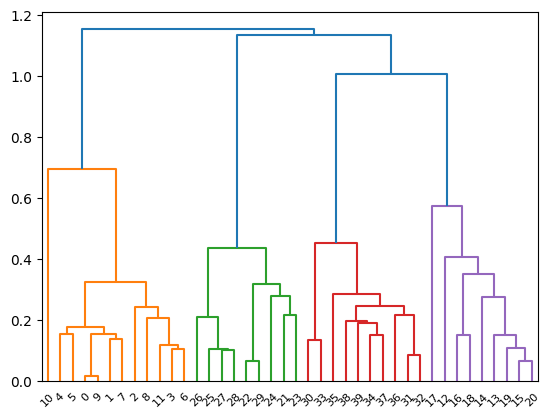

In [225]:
##Answer to question 4.1

import scipy.io as si
import scipy.cluster.hierarchy as sch

#reading the data:
data = si.loadmat('data/synth1.mat')['X_test']
#print(data)

#hirarchical clustering in a matrix representation:
clustering = sch.linkage(data, method='single', metric='euclidean')
#print(clustering)

#clustering with 4 clusters:
cls = sch.fcluster(clustering, criterion='maxclust', t=4)

#plotting the dendrogram:
dendro = sch.dendrogram(clustering)

#plotting the scatterplot:
#cp.clusterPlot(data)

### Exercise 4.2
Change the linkage methods (single, complete, average) for the `synth1` dataset and **explain** how this changes the dendrogram (plot all 3 dendrograms) and make a scatterplot of the best performing method. Argue why you think this linkage method performs best. If several linkage methods perform similarly, describe why. Repeat this exercise for the `synth2`, `synth3`, and `synth4` datasets. 

In [ ]:
##Answer to question 4.2
# YOUR CODE HERE
raise NotImplementedError()

YOUR ANSWER

## Exercise 5
Read https://proceedings.neurips.cc/paper_files/paper/2002/file/43e4e6a6f341e00671e123714de019a8-Paper.pdf and answer the following questions:

 1. Briefly explain what scale-invariance, richness and consistency each mean.
 2. Why do we want all 3?
 3. Briefly and informally: why can't all 3 hold at the same time?
 4. What impact does it have that not all 3 can hold at the same time? (Think about why different methods give different results)

YOUR ANSWER

# **Part B**

## Exercise B.1 - Practical applications of k-means


*k*-means clustering has many different applications, one of which is data compression. A data set can be compressed by performing *k*-means clustering and then representing each data object by the centroid of the corresponding cluster. Thus, the only data that need to be stored are the *K* cluster centers and the *N* cluster indices.

### Exercise B.1.1
We will take another look at the MNIST digits data. Load the  data, `data/digits.mat` using the `loadmat` function. Each data object is a $16 \times 16 = 256$ dimensional vector, corresponding to a grayscale $16 \times 16$ pixels image. Compute a *k*-means clustering of the data with *K = 10* clusters. Plot a few random images from the data set as well as their corresponding cluster centroids to see how they are represented.

**Helpful hint:**
+ You can plot an image by the command `imshow(np.reshape(X[k,:],(x,y)))` which reshapes an image vector to a 2-dimensional array and plots it. You can plot the cluster centroids in a similar manner.
+ If you can not figure out how to get 1.1 working, you can use the function `KMeans()` from the package sklearn.cluster to compute *k*-means clustering. please read the documentation of the function, as it creates an object which you can then use for clustering.


In [ ]:
## Answer to exercise 2.1
raise NotImplementedError()

### Exercise B.1.2
How well is the data represented by the cluster centroids? Why does running *k*-means with *K = 10* not give you 10 clusters corresponding to the 10 digits *0..9*? How many clusters do you need to visually represent the 10 different digits? Are there any digits that the clustering algorithm seems to confuse more than others and can you explain why?

YOUR ANSWER

## Exercise B.2
For further practice, e.g. to prepare for the exam:
    Do excercises 5,6,17, 20 in section 5.7 in TSKK.

# Handing in
Hand in the filled-in notebook:
- Make sure your names and student-numbers are mentioned at the appropriate location at the top of this file.
- Make sure you wrote a serious attempt for all exercises in part A
- Make sure the notebook is named groupnumber_assignment9.ipynb

When you are confident all of this is correctly done, one of you can hand in the exercises in Brightspace!